Abishek Thapa S398450

## 1. Analytical Question

Do teams that win matches have significantly higher shot accuracy than teams that lose matches?

I wanted to find out if teams that win football matches also have better shot accuracy than teams that lose. I used data from FIFA matches in 2026, which came in two files: one with match results, and one with team stats like total shots and shots on target.


In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# importing all the required libraries
import os
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

folder = "/content/drive/MyDrive/fifamatches2026"

# Defining file paths in a folder
matches_path = os.path.join(folder, "matches.csv")
stats_path = os.path.join(folder, "match_team_stats.csv")

# Load the datasets
matches = pd.read_csv(matches_path)
team_stats = pd.read_csv(stats_path)

print("Matches loaded:", matches.shape)
print("Team statistics loaded:", team_stats.shape)

Matches loaded: (104, 17)
Team statistics loaded: (208, 12)


## 2. Data Wrangling


Here, What I did first is I worked out if each team won, lost, or drew, by comparing the goals (and penalty scores if the match went to penalties). Then I joined this result information with the team stats, and worked out shot accuracy for each team using this formula: shots on target divided by total shots, then multiplied by 100.

In [3]:
# Creating a list to store the outcome of each team's performance
match_results = []

# Processing every match rows individually and comparing
for _, row in matches.iterrows():

    # Case 1: If home team scored more goals then home team win and away team loses
    if row["home_score"] > row["away_score"]:
        home_result = "Win"
        away_result = "Loss"

    # Case 2: If away team scored more goals then away team wins and home team loses
    elif row["away_score"] > row["home_score"]:
        home_result = "Loss"
        away_result = "Win"

    # Case 3: If the scores were equal then we check if game was decided by penalty shootout
    else:

        # Checking whether the match was decided by a penalty shootout
        if (
            pd.notna(row["home_penalty_score"])
            and pd.notna(row["away_penalty_score"])
        ):

            # If home team won the penalty shootout
            if row["home_penalty_score"] > row["away_penalty_score"]:
                home_result = "Win"
                away_result = "Loss"

            # If away team won the penalty shootout
            elif row["away_penalty_score"] > row["home_penalty_score"]:
                home_result = "Loss"
                away_result = "Win"

            # If penalty scores were also equal
            else:
                home_result = "Draw"
                away_result = "Draw"

        # Match remained a draw
        else:
            home_result = "Draw"
            away_result = "Draw"

    # Now, storing the home team's result
    match_results.append({
        "match_id": row["match_id"],
        "team_id": row["home_team_id"],
        "outcome": home_result
    })

    # Store the away team's result
    match_results.append({
        "match_id": row["match_id"],
        "team_id": row["away_team_id"],
        "outcome": away_result
    })

# Converting the results into a DataFrame
outcomes = pd.DataFrame(match_results)

print("Team-match outcomes:")
display(outcomes.head())

print("\nOutcome distribution:")
print(outcomes["outcome"].value_counts())

Team-match outcomes:


,match_id,team_id,outcome
0,1,1,Win
1,1,2,Loss
2,2,3,Win
3,2,4,Loss
4,3,5,Draw



Outcome distribution:
outcome
Win     83
Loss    83
Draw    42
Name: count, dtype: int64


In [4]:
# Then I merge the datasets and calculate a shot accuracy
# Combining the team statistics with the corresponding match outcome in team_stats
df = pd.merge(
    team_stats,
    outcomes,
    on=["match_id", "team_id"],
    how="inner"
)

print("The combined dataset shape: ", df.shape)

# Calculating the shot accuracy
# Formule used to calculate, Shot accuracy = (shots on target / total shots) × 100
df["shot_accuracy"] = (
    df["shots_on_target"] / df["total_shots"]
) * 100

# Display the variables relevant to this analysis
display(
    df[
        [
            "match_id",
            "team_id",
            "total_shots",
            "shots_on_target",
            "shot_accuracy",
            "outcome"
        ]
    ].head(10)
)

The combined dataset shape:  (208, 13)


,match_id,team_id,total_shots,shots_on_target,shot_accuracy,outcome
0,1,1,16,4,25.000000,Win
1,1,2,3,2,66.666667,Loss
2,2,3,12,5,41.666667,Win
3,2,4,10,3,30.000000,Loss
4,3,5,13,4,30.769231,Draw
5,3,6,8,3,37.500000,Draw
6,4,13,16,6,37.500000,Win
7,4,14,9,1,11.111111,Loss
8,5,7,6,3,50.000000,Draw
9,5,8,26,7,26.923077,Draw


## 3. Data Preparation and Sampling


After that, I cleaned the data a little. I only kept the matches that ended in a win or a loss, because draws don't help answer this question. I also removed any team performance with fewer than 5 total shots, because with very few shots the accuracy percentage can look misleading.

In [5]:
# Now, Preparing the data and
# Keeping only winning and losing performances of easy and effective analysis.
# I, exclude draws as we only need winners and loosers.
analysis_data = df[
    df["outcome"].isin(["Win", "Loss"])
].copy()

# Remove performances with fewer than five total shots.
# Because, very small shooting samples can produce unstable accuracy percentages so we remove it.
analysis_data = analysis_data[
    analysis_data["total_shots"] >= 5
].copy()

# Removing records where shot accuracy could not be calculated
analysis_data = analysis_data.dropna(
    subset=["shot_accuracy"]
)

print("Records after data preparation:", len(analysis_data))

print("\nOutcome counts:")
print(analysis_data["outcome"].value_counts())

print("\nMissing shot accuracy values:")
print(analysis_data["shot_accuracy"].isnull().sum())

Records after data preparation: 160

Outcome counts:
outcome
Win     83
Loss    77
Name: count, dtype: int64

Missing shot accuracy values:
0


Sampling



Then I took an 80% random sample of the winning and losing performances, using a fixed random seed so anyone can repeat the same result.  

In [6]:
# Creating a stratified random sample.
# Sampling separately from the Win and Loss groups ensures that
# both groups are represented in the final analytical sample.
# A fixed random state of 42 was used to make the sampling reproducible.
sample_fraction = 0.80

sampled_data = (
    analysis_data
    .groupby("outcome", group_keys=False)
    .apply(
        lambda group: group.sample(
            frac=sample_fraction,
            random_state=42
        )
    )
    .reset_index(drop=True)
)

print("Total observations before sampling:", len(analysis_data))
print("Total observations after sampling:", len(sampled_data))

print("\nSample size by outcome:")
print(sampled_data["outcome"].value_counts())

Total observations before sampling: 160
Total observations after sampling: 128

Sample size by outcome:
outcome
Win     66
Loss    62
Name: count, dtype: int64


/tmp/ipykernel_71785/2869334786.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [7]:
# Separating the sampled data according to winning team  match performance and
# losing performances
winning_accuracy = sampled_data.loc[
    sampled_data["outcome"] == "Win",
    "shot_accuracy"
]

losing_accuracy = sampled_data.loc[
    sampled_data["outcome"] == "Loss",
    "shot_accuracy"
]

print("Winning performances:", len(winning_accuracy))
print("Losing performances:", len(losing_accuracy))

Winning performances: 66
Losing performances: 62


##4. Descriptive Statistics


In [8]:
# Calculate descriptive statistics for both groups
summary = sampled_data.groupby("outcome")["shot_accuracy"].describe()

print("Descriptive Statistics")
display(summary.round(2))

# Display the mean difference separately
mean_winners = winning_accuracy.mean()
mean_losers = losing_accuracy.mean()

print(f"\nMean shot accuracy of winners: {mean_winners:.2f}%")
print(f"Mean shot accuracy of losers: {mean_losers:.2f}%")
print(
    f"Difference in mean shot accuracy: "
    f"{mean_winners - mean_losers:.2f} percentage points"
)

Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max
outcome,,,,,,,,
Loss,62.0,29.22,13.57,0.0,20.00,29.29,37.5,60.0
Win,66.0,42.38,11.49,20.0,33.33,43.17,50.0,80.0



Mean shot accuracy of winners: 42.38%
Mean shot accuracy of losers: 29.22%
Difference in mean shot accuracy: 13.16 percentage points


## 5. Inferential Statistics (95% Confidence Interval)

I compared the average shot accuracy of winning performances against losing performances, and calculated a 95% confidence interval for the difference between the two.

In [9]:
# Calculating a 95% confidence interval for the difference
# between the mean shot accuracy of winners and losers.

ci_result = stats.ttest_ind(
    winning_accuracy,
    losing_accuracy,
    equal_var=False,
    alternative="two-sided"
).confidence_interval(confidence_level=0.95)

mean_difference = mean_winners - mean_losers

print("95% Confidence Interval")
print(f"Mean difference: {mean_difference:.2f} percentage points")
print(
    f"95% Confidence Interval: "
    f"[{ci_result.low:.2f}, {ci_result.high:.2f}]"
)

95% Confidence Interval
Mean difference: 13.16 percentage points
95% Confidence Interval: [8.74, 17.57]


## 6. Inferential Statistics (Welch's two-sample t-test)

Finally, I used Welch's t-test, which is a statistical test used for comparing the averages of two groups, to check if the difference was statistically significant, and I made a boxplot to show the two distributions visually.


In [11]:
# Welch's independent two-sample t-test compares the mean shot
# accuracy of winning and losing team-match performances.

# H0: There is no difference in average shot accuracy between winning and losing performances.
# H1: Winning performances have higher average shot accuracy than losing performances.

# A one-sided test is used because we need weather winner have higher shot accuracy or not.

t_stat, p_value = stats.ttest_ind(
    winning_accuracy,
    losing_accuracy,
    equal_var=False,
    alternative="greater"
)

print("Welch's Two-Sample t-Test")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Statistical decision using a 5% significance level
alpha = 0.05

if p_value < alpha:
    print("\nDecision: Reject the null hypothesis.")
    print(
        "There is statistically significant evidence that "
        "winning performances have higher shot accuracy."
    )
else:
    print("\nDecision: Fail to reject the null hypothesis.")
    print(
        "There is not enough statistical evidence to conclude "
        "that winning performances have higher shot accuracy."
    )

Welch's Two-Sample t-Test
t-statistic: 5.9024
p-value: 0.0000

Decision: Reject the null hypothesis.
There is statistically significant evidence that winning performances have higher shot accuracy.


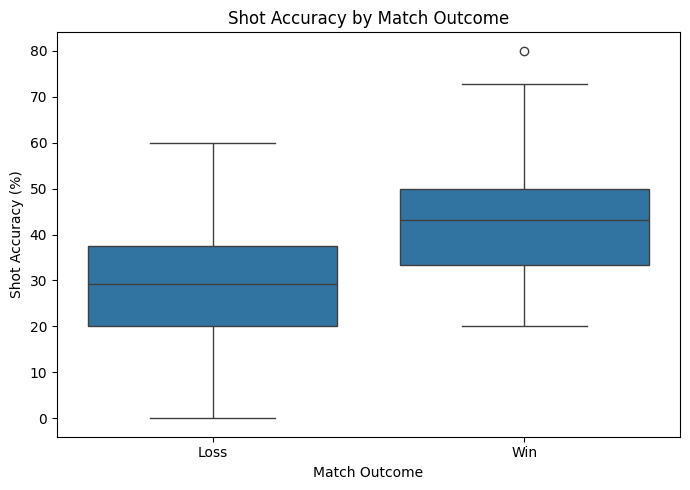

In [12]:
# Visual representation using boxplot showing the distribution of shot accuracy
# for winning and losing team-match performances.

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=sampled_data,
    x="outcome",
    y="shot_accuracy"
)

plt.title("Shot Accuracy by Match Outcome")
plt.xlabel("Match Outcome")
plt.ylabel("Shot Accuracy (%)")

plt.tight_layout()
plt.show()

## Conclusion

The analysis shows a clear difference in shot accuracy between teams that won and teams that lost. On average, winning teams had a shot accuracy of around 42.4%, compared with 29.2% for losing teams. This is a difference of approximately 13.2 percentage points. The 95% confidence interval for this difference was between 8.74 and 17.57 percentage points, which does not include zero. This suggests that the difference in shot accuracy is unlikely to be due to random variation in the data.

The Welch’s t-test also supports this finding. The test produced a t-statistic of approximately 5.90 and a p-value much lower than 0.05. Therefore, the null hypothesis was rejected, providing strong evidence that winning teams generally have higher shot accuracy than losing teams.

Overall, the results suggest that shot accuracy is an important factor associated with winning a match. Teams that are more accurate with their shots appear to have a better chance of winning. However, shot accuracy alone does not determine the outcome of a football match. Other factors, such as defending, goalkeeping, passing, possession, and sometimes luck, can also influence the final result. Even so, the results from this analysis show a clear relationship between better shot accuracy and match success.